In [1]:
!pip install tensorflow opencv-python matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.21.0
[]


In [3]:
import tensorflow as tf
import os

In [19]:
#remove unwanted images
import cv2
import matplotlib.pyplot as plt

In [5]:
!pip install pillow

Defaulting to user installation because normal site-packages is not writeable


In [6]:
data_dir= r"D:\Projects\Image_classifier\data"

In [7]:
os.listdir(data_dir)

['happy', 'sad']

In [8]:
image_exts= ['jpeg', 'jpg', 'bmp', 'png']

In [9]:
os.listdir(os.path.join(data_dir, 'happy'))

['imgi_101_images.jpg',
 'imgi_103_images.jpg',
 'imgi_104_images.jpg',
 'imgi_105_images.jpg',
 'imgi_106_images.jpg',
 'imgi_107_images.jpg',
 'imgi_109_images.jpg',
 'imgi_10_images.jpg',
 'imgi_111_images.jpg',
 'imgi_113_images.jpg',
 'imgi_115_images.jpg',
 'imgi_116_images.jpg',
 'imgi_117_images.jpg',
 'imgi_119_images.jpg',
 'imgi_11_images.jpg',
 'imgi_121_images.jpg',
 'imgi_123_images.jpg',
 'imgi_125_images.jpg',
 'imgi_126_images.jpg',
 'imgi_128_images.jpg',
 'imgi_130_images.jpg',
 'imgi_131_images.jpg',
 'imgi_133_images.jpg',
 'imgi_135_images.jpg',
 'imgi_136_images.jpg',
 'imgi_137_images.jpg',
 'imgi_138_images.jpg',
 'imgi_140_images.jpg',
 'imgi_141_images.jpg',
 'imgi_142_images.jpg',
 'imgi_144_images.jpg',
 'imgi_145_images.jpg',
 'imgi_146_images.jpg',
 'imgi_147_images.jpg',
 'imgi_149_images.jpg',
 'imgi_14_images.jpg',
 'imgi_150_images.jpg',
 'imgi_152_images.jpg',
 'imgi_154_images.jpg',
 'imgi_156_images.jpg',
 'imgi_158_images.jpg',
 'imgi_160_images.j

In [10]:
import os

os.chdir(r"D:\Projects\Image_classifier")

print(os.getcwd())

D:\Projects\Image_classifier


In [11]:
from PIL import Image
import os

image_exts = ['jpeg', 'jpg', 'bmp', 'png']

for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)

    if not os.path.isdir(class_path):
        continue

    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)

        try:
            with Image.open(image_path) as img:
                img.verify()                  # Verify integrity
                img_format = img.format.lower()

            if img_format not in image_exts:
                print(f"Removing: {image_path}")
                os.remove(image_path)

        except Exception as e:
            print(f"Corrupted image: {image_path}")
            print(e)
            os.remove(image_path)

In [12]:
img= cv2.imread(os.path.join('data', 'happy', 'imgi_3_default.jpg'))

In [13]:
type(img)

numpy.ndarray

In [14]:
import os

path = os.path.join('data', 'happy', 'imgi_3_default.jpg')

print(path)
print(os.path.exists(path))

data\happy\imgi_3_default.jpg
True


In [15]:
image_path = os.path.join(data_dir, image_class, image)

img = cv2.imread(image_path)

In [16]:
img

array([[[227, 227, 227],
        [227, 227, 227],
        [228, 228, 228],
        ...,
        [199, 199, 199],
        [197, 197, 197],
        [197, 197, 197]],

       [[227, 227, 227],
        [227, 227, 227],
        [228, 228, 228],
        ...,
        [199, 199, 199],
        [198, 198, 198],
        [197, 197, 197]],

       [[227, 227, 227],
        [227, 227, 227],
        [228, 228, 228],
        ...,
        [200, 200, 200],
        [198, 198, 198],
        [198, 198, 198]],

       ...,

       [[182, 182, 182],
        [183, 183, 183],
        [184, 184, 184],
        ...,
        [187, 187, 187],
        [186, 186, 186],
        [186, 186, 186]],

       [[180, 180, 180],
        [181, 181, 181],
        [182, 182, 182],
        ...,
        [187, 187, 187],
        [186, 186, 186],
        [185, 185, 185]],

       [[179, 179, 179],
        [179, 179, 179],
        [180, 180, 180],
        ...,
        [186, 186, 186],
        [185, 185, 185],
        [185, 185, 185]]

In [17]:
img= cv2.imread(os.path.join('data', 'happy', 'imgi_3_default.jpg'))
img.shape

(46, 69, 3)

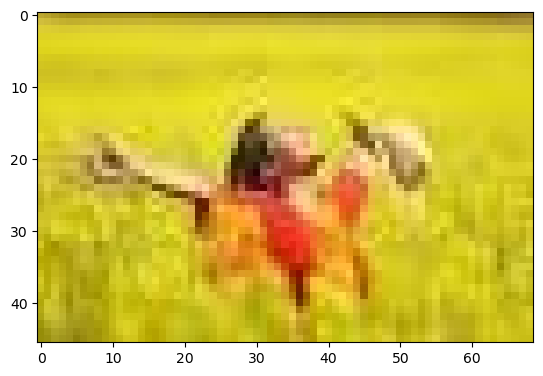

In [20]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [21]:
data= data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(256, 256),
    batch_size=32,
    shuffle=True,
    seed=42
)

Found 291 files belonging to 2 classes.


In [22]:
data_iterator= data.as_numpy_iterator()

In [23]:
#get another batch from the iterator
batch= data_iterator.next()

In [24]:
len(batch)

2

In [25]:
#Images represented as numpy arrays
batch[0].shape

(32, 256, 256, 3)

In [26]:
#class 1= sad people
#class 0= happy people
batch[1] 

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0], dtype=int32)

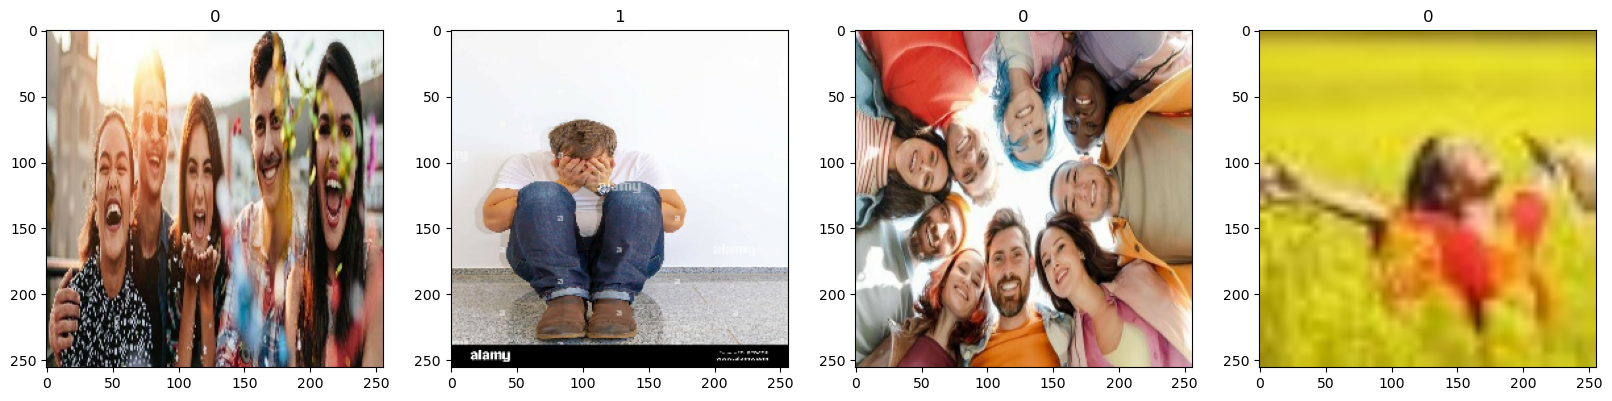

In [27]:
fig, ax= plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

Preprocess Data 

In [28]:
# scale data
data = data.map(lambda x, y: (x / 255.0, y))

In [29]:
AUTOTUNE = tf.data.AUTOTUNE
data = data.prefetch(AUTOTUNE)

In [30]:
data.as_numpy_iterator().next()

(array([[[[0.9607843 , 0.9647059 , 0.94509804],
          [0.9607843 , 0.9647059 , 0.94509804],
          [0.9607843 , 0.9647059 , 0.94509804],
          ...,
          [0.9882353 , 0.99215686, 0.972549  ],
          [0.9882353 , 0.99215686, 0.972549  ],
          [0.9882353 , 0.99215686, 0.972549  ]],
 
         [[0.9607843 , 0.9647059 , 0.94509804],
          [0.9607843 , 0.9647059 , 0.94509804],
          [0.9607843 , 0.9647059 , 0.94509804],
          ...,
          [0.9882353 , 0.99215686, 0.972549  ],
          [0.9882353 , 0.99215686, 0.972549  ],
          [0.9882353 , 0.99215686, 0.972549  ]],
 
         [[0.9607843 , 0.9647059 , 0.94509804],
          [0.9607843 , 0.9647059 , 0.94509804],
          [0.9607843 , 0.9647059 , 0.94509804],
          ...,
          [0.9882353 , 0.99215686, 0.972549  ],
          [0.9882353 , 0.99215686, 0.972549  ],
          [0.9882353 , 0.99215686, 0.972549  ]],
 
         ...,
 
         [[0.99607843, 1.        , 0.98039216],
          [0.99607

In [31]:
batch[0].max()

np.float32(255.0)

Split the data

In [32]:
len(data)

10

In [33]:
train_size= int(len(data)*0.7)
val_size= int(len(data)*0.2)
test_size= int(len(data)*0.1)

In [34]:
train_size

7

In [35]:
val_size

2

In [36]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

Building deep learning model

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [38]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

augment = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [39]:
model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(256, 256, 3)
))

model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))

C:\Users\nived\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile('adam', loss= tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      29,491,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,584,961 (112.86 MB)

 Trainable params: 29,584,961 (112.86 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
logdir= 'data'

In [43]:
!pip install tensorboard

Defaulting to user installation because normal site-packages is not writeable


In [44]:
pip show tensorboard

Name: tensorboard
Version: 2.21.0
Summary: TensorBoard lets you watch Tensors Flow
Home-page: https://github.com/tensorflow/tensorboard
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\nived\AppData\Roaming\Python\Python313\site-packages
Requires: absl-py, grpcio, markdown, numpy, packaging, pillow, protobuf, setuptools, tensorboard-data-server, werkzeug
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [45]:
tensorboard_callback= tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [46]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [ ]:
hist = model.fit(
    train,
    validation_data=val,
    epochs=50,
    callbacks=[checkpoint]
)

Epoch 1/50


C:\Users\nived\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 754ms/step - accuracy: 0.4330 - loss: 3.1500 - val_accuracy: 0.6875 - val_loss: 0.6543
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 455ms/step - accuracy: 0.6161 - loss: 0.6712 - val_accuracy: 0.6562 - val_loss: 0.6428
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 444ms/step - accuracy: 0.7009 - loss: 0.5716 - val_accuracy: 0.6719 - val_loss: 0.7003
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 592ms/step - accuracy: 0.6741 - loss: 0.7764 - val_accuracy: 0.7031 - val_loss: 0.7348
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 565ms/step - accuracy: 0.6830 - loss: 0.7037 - val_accuracy: 0.8438 - val_loss: 0.6542
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 421ms/step - accuracy: 0.8036 - loss: 0.6599 - val_accuracy: 0.6562 - val_loss: 0.6460
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 429ms/step - accuracy: 0.7679 - loss: 0.5478 - val_accuracy: 0.7812 - val_loss: 0.4681
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 551ms/step - accuracy: 0.7723 - loss: 0.4877 - val_accuracy: 0.8906 - val_loss: 0.4000
Epo

In [172]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

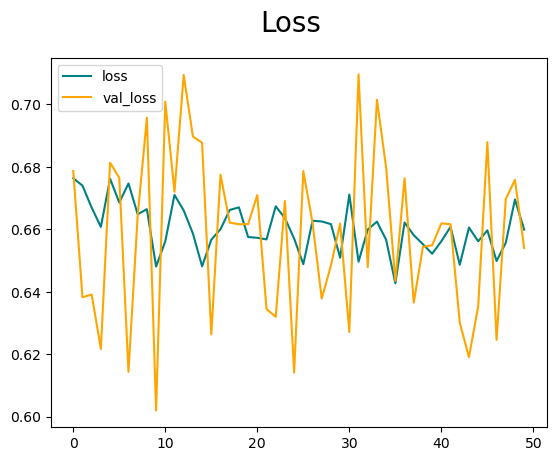

In [173]:
fig= plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label= 'val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc='upper left')
plt.show()

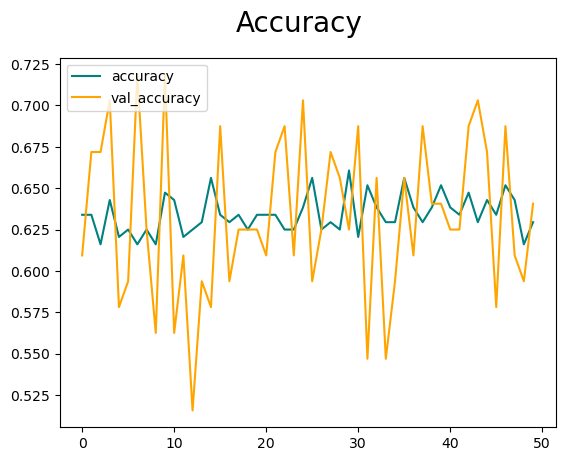

In [174]:
fig= plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label= 'val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc='upper left')
plt.show()

Evaluate Performance

In [175]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [176]:
pre= Precision()
re= Recall()
acc= BinaryAccuracy()

In [177]:
for batch in test.as_numpy_iterator():
    x,y= batch
    yhat= model.predict(x)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


In [178]:
print(f'Precision:{pre.result().numpy()}, Recall:{re.result().numpy()}, Accuray:{acc.result().numpy()}')

Precision:0.0, Recall:0.0, Accuray:1.0


In [179]:
for batch in test.as_numpy_iterator():
    x, y = batch
    yhat = model.predict(x)

    print("Actual Labels:")
    print(y)

    print("Predicted Probabilities:")
    print(yhat.flatten())

    print("Predicted Labels:")
    print((yhat > 0.5).astype(int).flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Actual Labels:
[0 1 0]
Predicted Probabilities:
[0.38010496 0.3801055  0.3801045 ]
Predicted Labels:
[0 0 0]
